# Kiểm tra số lượng ảnh trong Dataset Aligned
Đoạn code này sẽ đếm số lượng ảnh trong từng thư mục của `dataset_aligned` và hiển thị trực quan.

=== Báo cáo cho C:\Users\Admin\Desktop\Project_DAT301m\dataset_final\train ===
Tổng số folder: 432
Tổng số ảnh: 248400
Folder nhiều ảnh nhất: n000001 (575 ảnh)
Folder ít ảnh nhất: n001293 (575 ảnh)

Top 10 folder nhiều ảnh nhất:
 - n000001: 575 ảnh
 - n000002: 575 ảnh
 - n000003: 575 ảnh
 - n000004: 575 ảnh
 - n000006: 575 ảnh
 - n000007: 575 ảnh
 - n000008: 575 ảnh
 - n000010: 575 ảnh
 - n000011: 575 ảnh
 - n000013: 575 ảnh


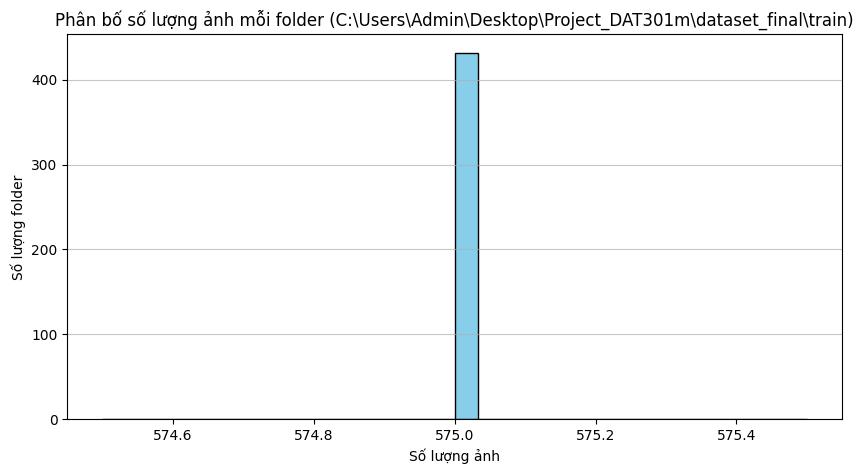



=== Báo cáo cho C:\Users\Admin\Desktop\Project_DAT301m\dataset_final\val ===
Tổng số folder: 432
Tổng số ảnh: 31327
Folder nhiều ảnh nhất: n000270 (143 ảnh)
Folder ít ảnh nhất: n000135 (30 ảnh)

Top 10 folder nhiều ảnh nhất:
 - n000270: 143 ảnh
 - n000419: 137 ảnh
 - n000266: 135 ảnh
 - n000472: 131 ảnh
 - n001242: 128 ảnh
 - n000234: 127 ảnh
 - n000225: 124 ảnh
 - n000302: 122 ảnh
 - n000314: 122 ảnh
 - n000395: 120 ảnh


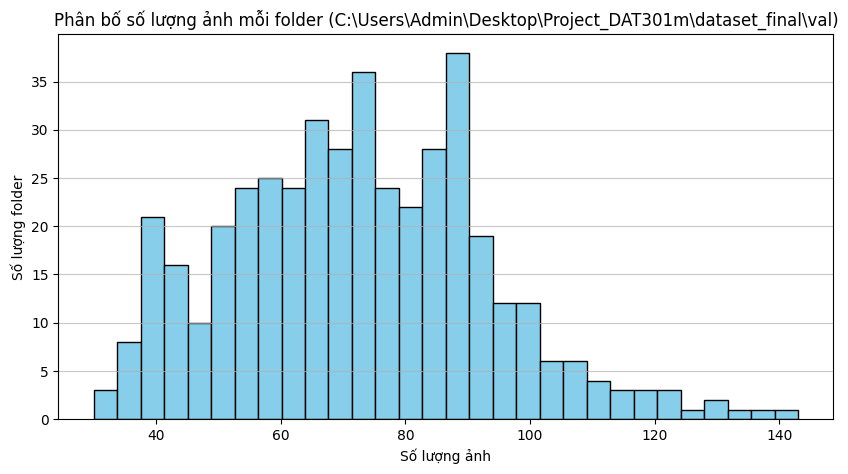



=== Báo cáo cho C:\Users\Admin\Desktop\Project_DAT301m\dataset_final\test ===
Tổng số folder: 108
Tổng số ảnh: 39095
Folder nhiều ảnh nhất: n000202 (642 ảnh)
Folder ít ảnh nhất: n000493 (101 ảnh)

Top 10 folder nhiều ảnh nhất:
 - n000202: 642 ảnh
 - n000097: 597 ảnh
 - n000080: 594 ảnh
 - n001146: 591 ảnh
 - n000282: 580 ảnh
 - n000185: 552 ảnh
 - n000378: 530 ảnh
 - n000667: 524 ảnh
 - n000149: 521 ảnh
 - n000358: 519 ảnh


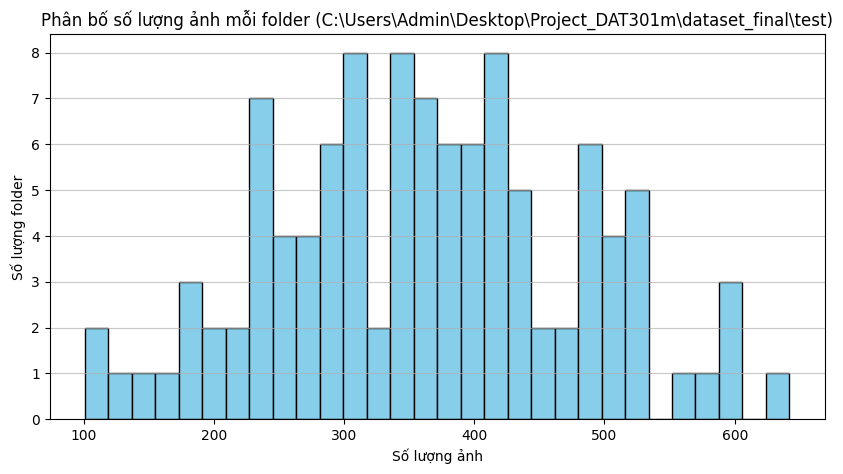

In [1]:
import os
import matplotlib.pyplot as plt

def check_image_counts(dataset_dir):
    if not os.path.exists(dataset_dir):
        print(f"Thư mục {dataset_dir} không tồn tại.\n")
        return
        
    classes = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]
    if not classes:
        print(f"Thư mục {dataset_dir} trống.\n")
        return

    counts = []
    
    for cls in classes:
        cls_path = os.path.join(dataset_dir, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        counts.append((cls, len(images)))
        
    # Sắp xếp theo số lượng ảnh giảm dần
    counts.sort(key=lambda x: x[1], reverse=True)
    
    print(f"=== Báo cáo cho {dataset_dir} ===")
    print(f"Tổng số folder: {len(counts)}")
    print(f"Tổng số ảnh: {sum(c[1] for c in counts)}")
    print(f"Folder nhiều ảnh nhất: {counts[0][0]} ({counts[0][1]} ảnh)")
    print(f"Folder ít ảnh nhất: {counts[-1][0]} ({counts[-1][1]} ảnh)\n")
    
    # In top 10
    print("Top 10 folder nhiều ảnh nhất:")
    for cls, count in counts[:10]:
        print(f" - {cls}: {count} ảnh")
        
    # Vẽ biểu đồ phân bố
    plt.figure(figsize=(10, 5))
    plt.hist([c[1] for c in counts], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Phân bố số lượng ảnh mỗi folder ({dataset_dir})")
    plt.xlabel("Số lượng ảnh")
    plt.ylabel("Số lượng folder")
    plt.grid(axis='y', alpha=0.7)
    plt.show()
    print("\n")

# Chạy kiểm tra
check_image_counts(r'C:\Users\Admin\Desktop\Project_DAT301m\dataset_final\train')
check_image_counts(r'C:\Users\Admin\Desktop\Project_DAT301m\dataset_final\val')
check_image_counts(r'C:\Users\Admin\Desktop\Project_DAT301m\dataset_final\test')
